# SAM-based Comb Detection (Point Prompts)

This notebook uses Segment Anything Model (SAM) with **point prompts** to detect honeybee comb regions.

## Approach

Your images have **two wooden frames side by side**:
- Place 2 point prompts: one in each frame (at 1/3 and 2/3 of width, centered vertically)
- SAM segments the objects at those locations
- Fast, memory-efficient, and accurate for consistent layouts

**Requirements:**
```bash
pip install segment-anything
```

**Download SAM checkpoint:**
- vit_h (best): https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

Save the checkpoint in your `models/` directory.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from datetime import datetime
from segmentation_restruct.comb_limitor import CombMaskGeneratorSAM, CombMaskEvaluator

## Setup

In [3]:
# Paths
root_dir = Path().cwd().resolve().parent.parent
model_dir = root_dir / 'models'
sam_checkpoint = model_dir / 'sam_vit_h_4b8939.pth'

# Data paths
images_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\images\test")
gt_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\labels\test")

# Verify checkpoint
if not sam_checkpoint.exists():
    print(f"⚠ SAM checkpoint not found: {sam_checkpoint}")
    print("Download from: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth")
else:
    print(f"✓ SAM checkpoint found: {sam_checkpoint.name}")

print(f"✓ Images directory: {images_dir}")
print(f"✓ Ground truth directory: {gt_dir}")

✓ SAM checkpoint found: sam_vit_h_4b8939.pth
✓ Images directory: E:\Bachelorarbeit\comb_limitation_dataset\images\test
✓ Ground truth directory: E:\Bachelorarbeit\comb_limitation_dataset\labels\test


In [4]:
# Initialize SAM generator with point prompt mode
generator = CombMaskGeneratorSAM(
    model_type="vit_h",
    checkpoint_path=str(sam_checkpoint),
    device="cuda"
)

# Initialize evaluator
evaluator = CombMaskEvaluator()

print("✓ SAM generator initialized (model will load on first use)")
print("✓ Evaluator initialized")

✓ SAM generator initialized (model will load on first use)
✓ Evaluator initialized


## Single Image Test

Test on one image to verify the approach works.

In [5]:
# Load a test image
test_images = sorted(list(images_dir.glob("*.png")))
if test_images:
    image_path = test_images[0]
    print(f"Loading: {image_path.name}")

    # Load image (SAM expects RGB)
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    print(f"Image shape: {image_rgb.shape}")
else:
    print("⚠ No test images found")

Loading: 20240606_cam-3.png
Image shape: (4608, 5312, 3)


In [6]:
# Generate comb mask with point prompts
# Two points: one for each frame at 1/3 and 2/3 width, centered vertically
comb_mask, metadata = generator.generate_comb_mask_points(
    image_rgb,
    height_ratio=0.5,           # Center vertically
    width_ratios=[0.33, 0.67],   # Two frames: 1/3 and 2/3 horizontally
    multimask_output=True
)

print(f"\n✓ Mask generated")
print(f"  Coverage: {np.sum(comb_mask) / comb_mask.size * 100:.1f}%")
print(f"  Score: {metadata['best_score']:.3f}")
print(f"  Points used: {metadata['num_points']}")

✓ SAM model loaded: vit_h
Using automatic point placement:
  Point 1: (1752, 2304) - width ratio 0.33
  Point 2: (3559, 2304) - width ratio 0.67
✓ Generated mask with 2 point prompt(s) (score: 0.957)

✓ Mask generated
  Coverage: 67.9%
  Score: 0.957
  Points used: 2
✓ Generated mask with 2 point prompt(s) (score: 0.957)

✓ Mask generated
  Coverage: 67.9%
  Score: 0.957
  Points used: 2


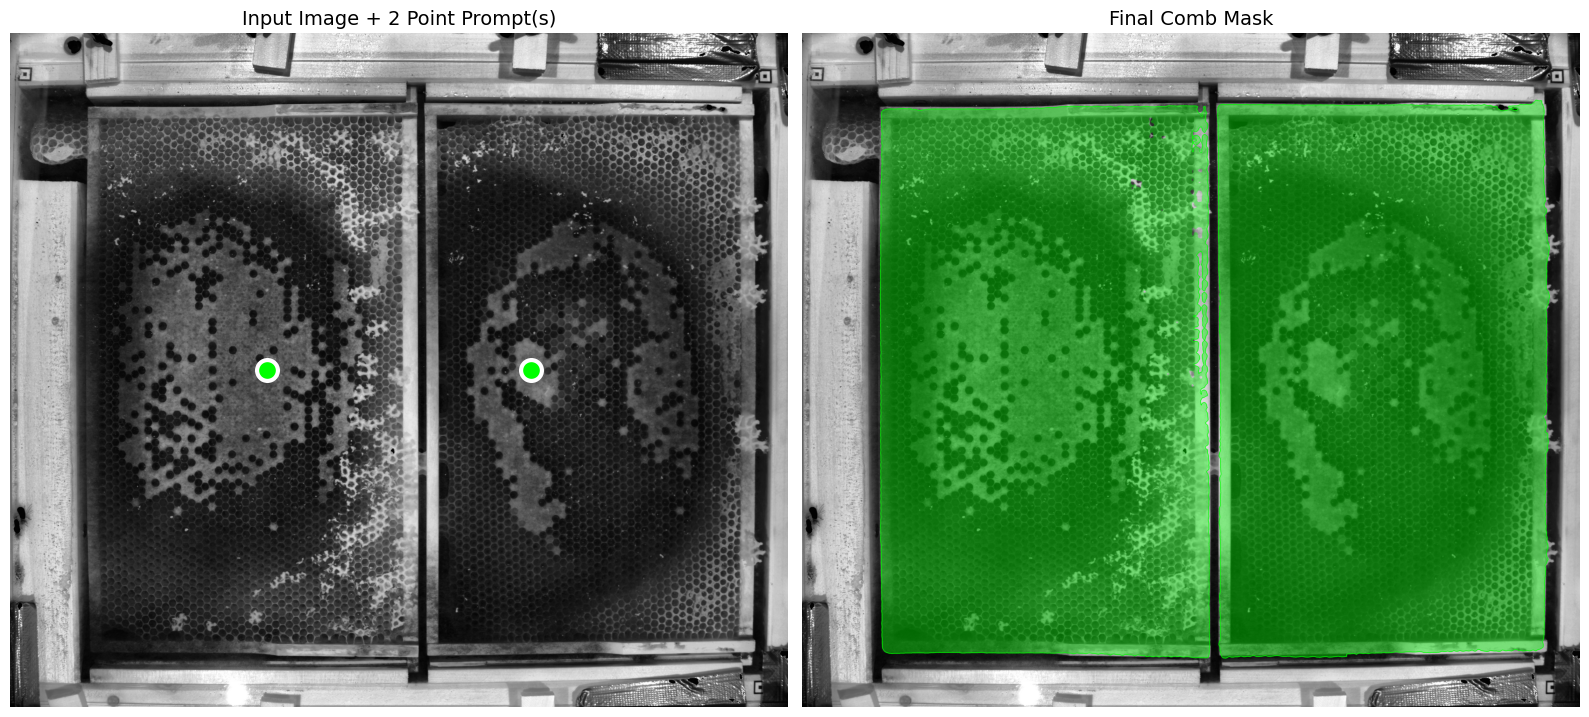

In [7]:
# Visualize: input image with point prompts + resulting mask
fig, axes = generator.visualize_detection(
    image_rgb,
    comb_mask,
    masks_metadata=metadata
)
plt.show()

## Batch Processing

Process all images in the dataset.

In [8]:
# Clear GPU memory before batch processing
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"✓ GPU memory cleared")
    print(f"  Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"  Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

✓ GPU memory cleared
  Allocated: 2.49 GB
  Reserved: 2.56 GB


In [9]:
# Process all images
image_files = sorted(images_dir.glob("*.png"))

predicted_masks = []
ground_truth_masks = []
input_images = []
image_names = []

print(f"Processing {len(image_files)} images with SAM (point prompts)...\n")

for img_file in image_files:
    gt_file = gt_dir / img_file.name

    if not gt_file.exists():
        print(f"⚠ Skipping {img_file.name} - no ground truth")
        continue

    print(f"Processing {img_file.name}...")

    # Load image
    img = cv2.imread(str(img_file))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Generate mask with SAM (2 point prompts)
    pred_mask, _ = generator.generate_comb_mask_points(
        img_rgb,
        height_ratio=0.5,
        width_ratios=[0.33, 0.67],
        multimask_output=True
    )

    # Load ground truth
    gt_mask = cv2.imread(str(gt_file), cv2.IMREAD_GRAYSCALE)

    # Store results
    predicted_masks.append(pred_mask)
    ground_truth_masks.append(gt_mask)
    input_images.append(img_gray)
    image_names.append(img_file.name)

print(f"\n✓ Processed {len(predicted_masks)} images successfully")

Processing 4 images with SAM (point prompts)...

Processing 20240606_cam-3.png...
Using automatic point placement:
  Point 1: (1752, 2304) - width ratio 0.33
  Point 2: (3559, 2304) - width ratio 0.67
✓ Generated mask with 2 point prompt(s) (score: 0.957)
Processing background_cam-0_20250719T012105.601863.038Z.png...
✓ Generated mask with 2 point prompt(s) (score: 0.957)
Processing background_cam-0_20250719T012105.601863.038Z.png...
Using automatic point placement:
  Point 1: (1752, 2304) - width ratio 0.33
  Point 2: (3559, 2304) - width ratio 0.67
Using automatic point placement:
  Point 1: (1752, 2304) - width ratio 0.33
  Point 2: (3559, 2304) - width ratio 0.67
✓ Generated mask with 2 point prompt(s) (score: 0.960)
Processing background_cam-3_20250705T043209.571836.965Z.png...
✓ Generated mask with 2 point prompt(s) (score: 0.960)
Processing background_cam-3_20250705T043209.571836.965Z.png...
Using automatic point placement:
  Point 1: (1752, 2304) - width ratio 0.33
  Point 2: (3

## Performance Evaluation

In [10]:
# Evaluate batch
aggregate_metrics, per_image_metrics = evaluator.evaluate_batch_from_arrays(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    image_names=image_names
)

# Print aggregate results
evaluator.print_metrics(aggregate_metrics, title="SAM Point Prompts - Batch Results")


             SAM Point Prompts - Batch Results              

Aggregate Statistics (n=4 images):

  Main Metrics:
IoU:      0.8524 +/- 0.0290  (range: 0.8096 - 0.8860)
Dice/F1:  0.9200 +/- 0.0170  (range: 0.8948 - 0.9396)
Accuracy: 0.8890 +/- 0.0222  (range: 0.8652 - 0.9226)

  Precision & Recall:
Precision:   0.8528 +/- 0.0288  (range: 0.8107 - 0.8866)
Recall:      0.9994 +/- 0.0007  (range: 0.9984 - 1.0000)
Specificity: 0.6834 +/- 0.0767  (range: 0.6046 - 0.8065)

  Confusion Matrix Totals:
True Positives  (TP): 62,784,558  (avg: 15,696,140 per image)
True Negatives  (TN): 24,255,657  (avg: 6,063,914 per image)
False Positives (FP): 10,836,761  (avg: 2,709,190 per image)
False Negatives (FN): 33,808  (avg: 8,452 per image)
Total pixels:         97,910,784



In [11]:
# Print per-image results
print("\n" + "="*60)
print("Per-Image Results:")
print("="*60)
for metrics in per_image_metrics:
    print(f"\n{metrics['filename']}:")
    print(f"  IoU: {metrics['iou']:.4f}  |  Dice: {metrics['dice']:.4f}  |  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}  |  Recall: {metrics['recall']:.4f}")


Per-Image Results:

20240606_cam-3.png:
  IoU: 0.8860  |  Dice: 0.9396  |  Accuracy: 0.9226
  Precision: 0.8866  |  Recall: 0.9992

background_cam-0_20250719T012105.601863.038Z.png:
  IoU: 0.8432  |  Dice: 0.9150  |  Accuracy: 0.8735
  Precision: 0.8432  |  Recall: 1.0000

background_cam-3_20250705T043209.571836.965Z.png:
  IoU: 0.8707  |  Dice: 0.9309  |  Accuracy: 0.8946
  Precision: 0.8707  |  Recall: 1.0000

k_background_cam-1_20250816T104412.249021.386Z--20250816T104512.171084.576Z.png:
  IoU: 0.8096  |  Dice: 0.8948  |  Accuracy: 0.8652
  Precision: 0.8107  |  Recall: 0.9984


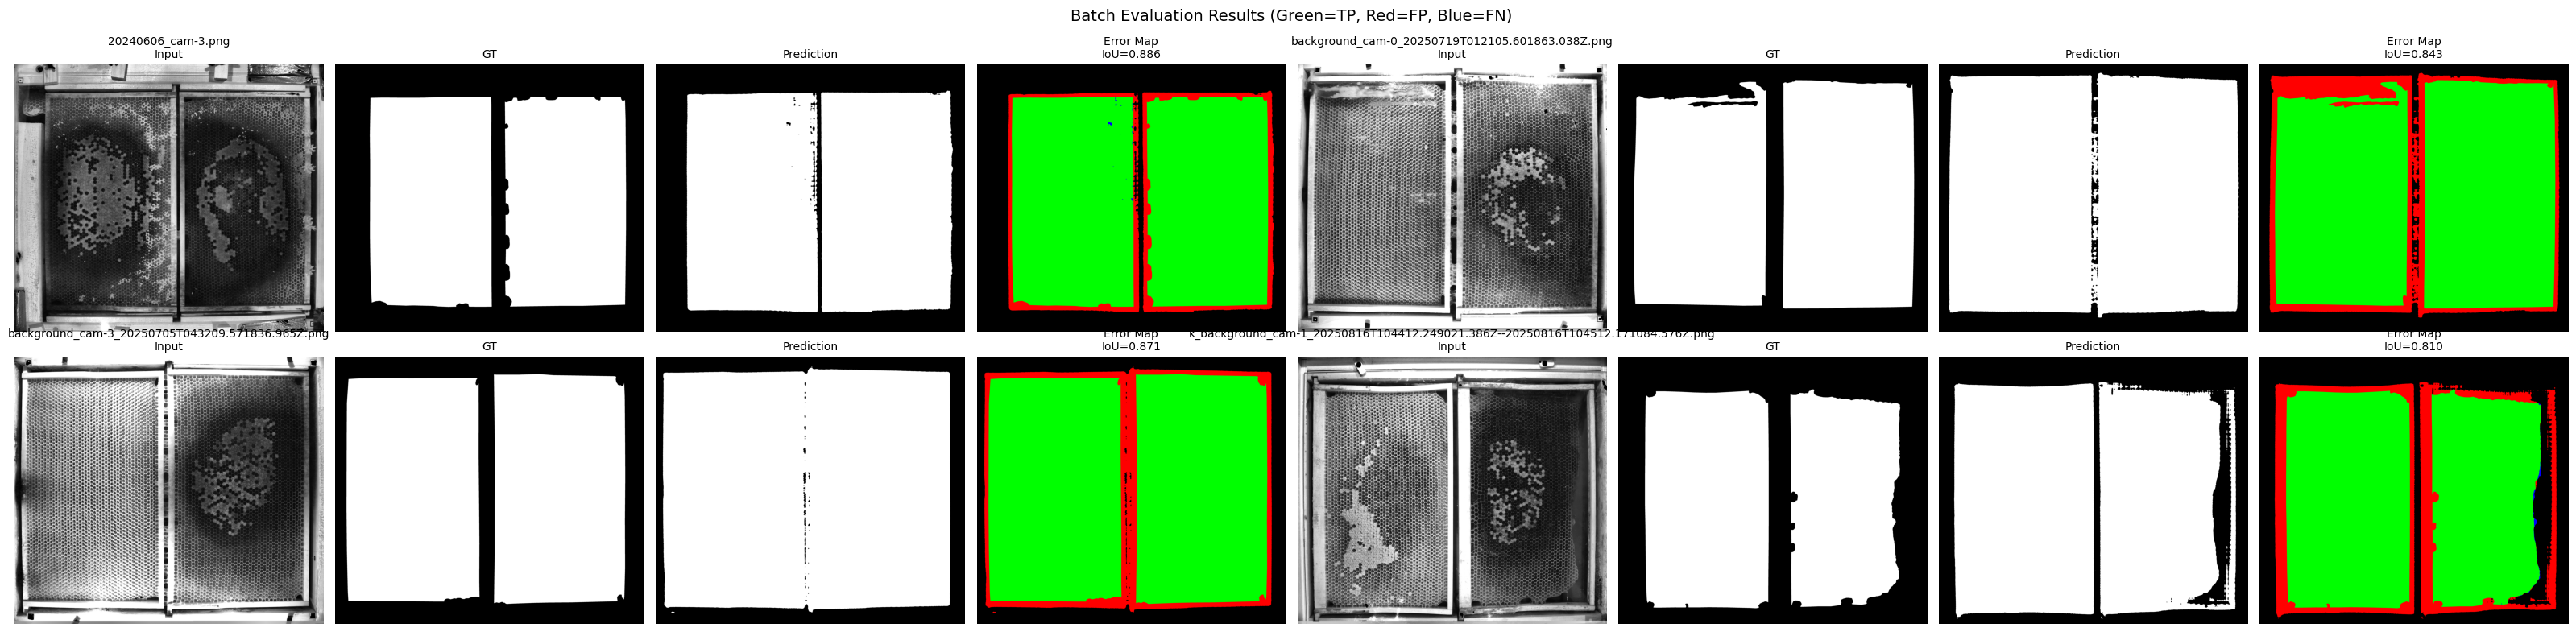

In [11]:
# Visualize all predictions
fig, axes = evaluator.visualize_batch(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    image_names=image_names,
    input_images=input_images,
    max_cols=2
)
plt.show()

## Generate Individual Plots for Thesis

Each sample gets its own clean figure (no titles, no names) - ready for your thesis.

Generated 4 individual figures


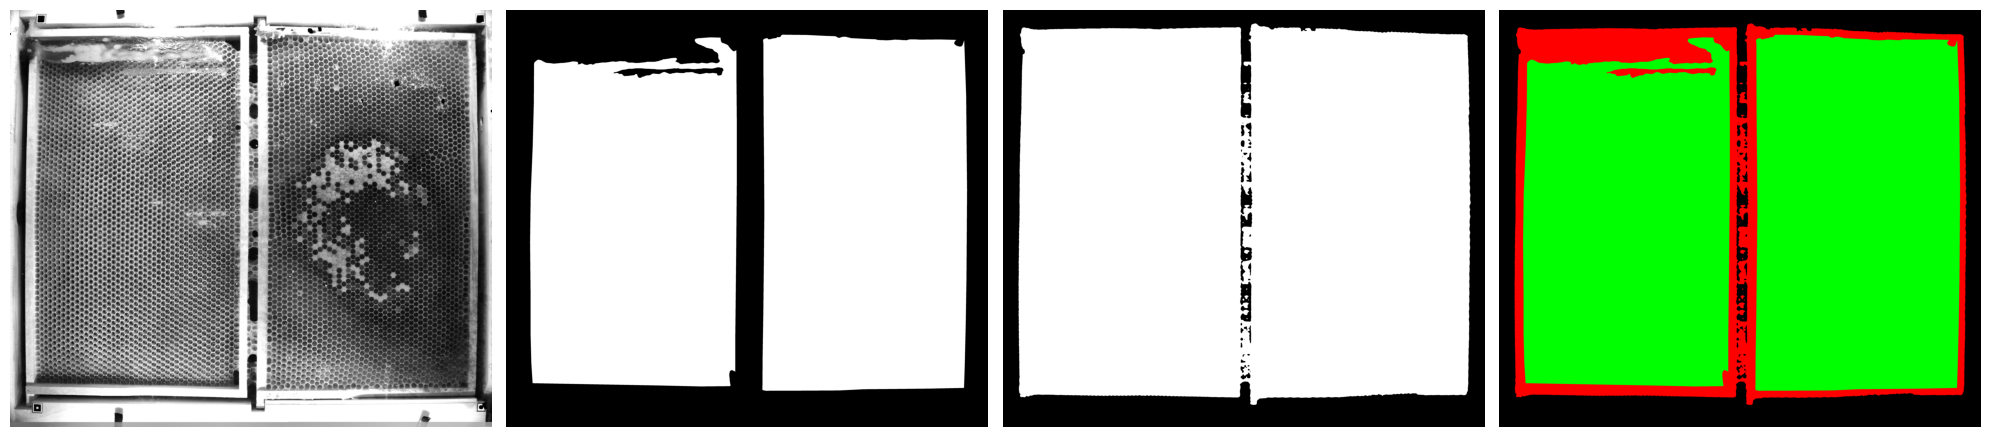

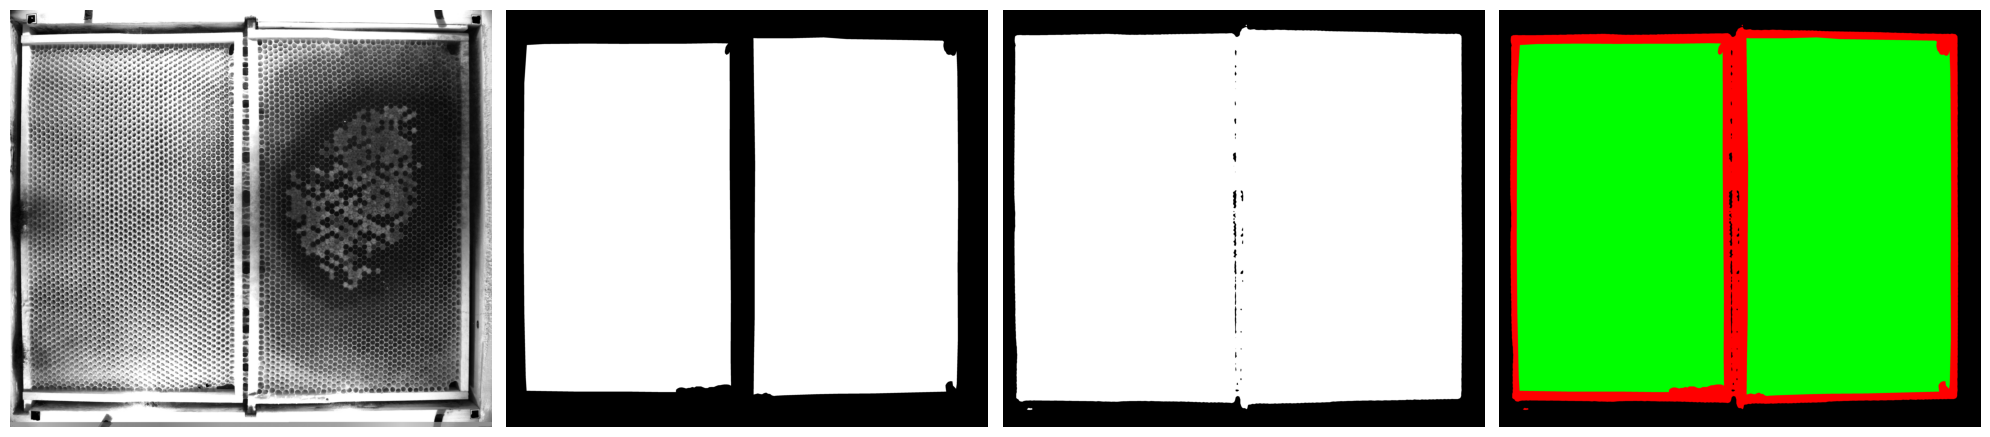

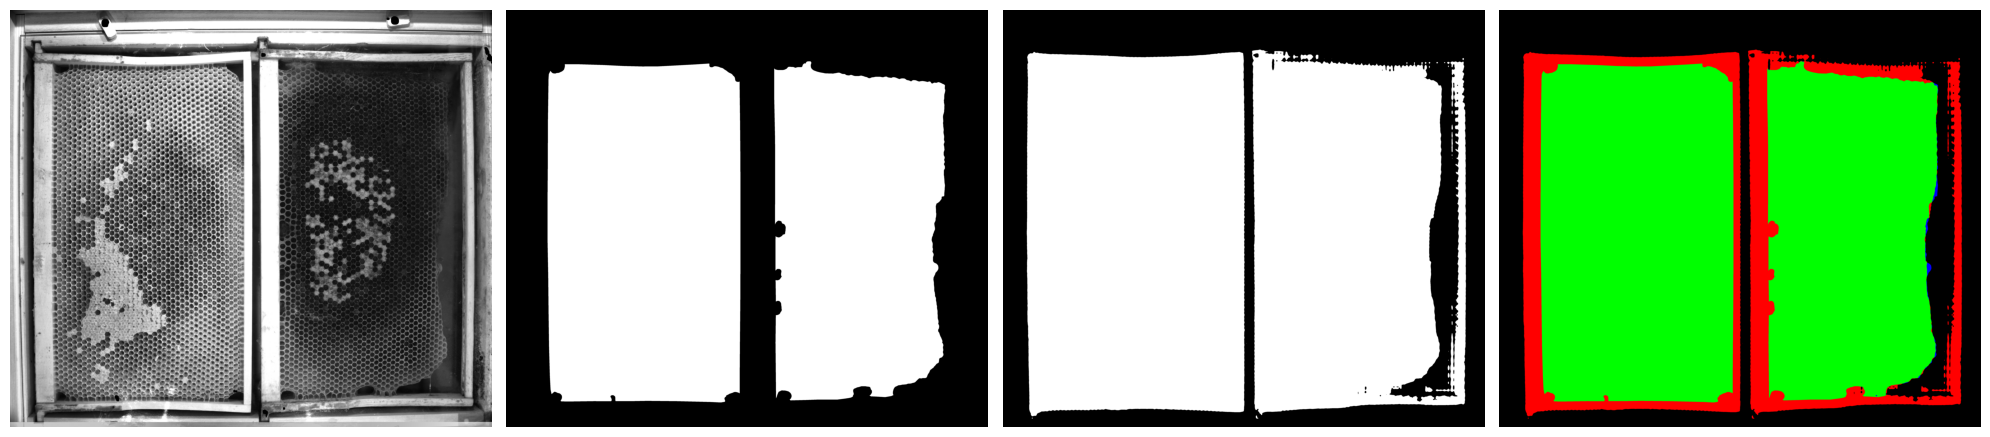

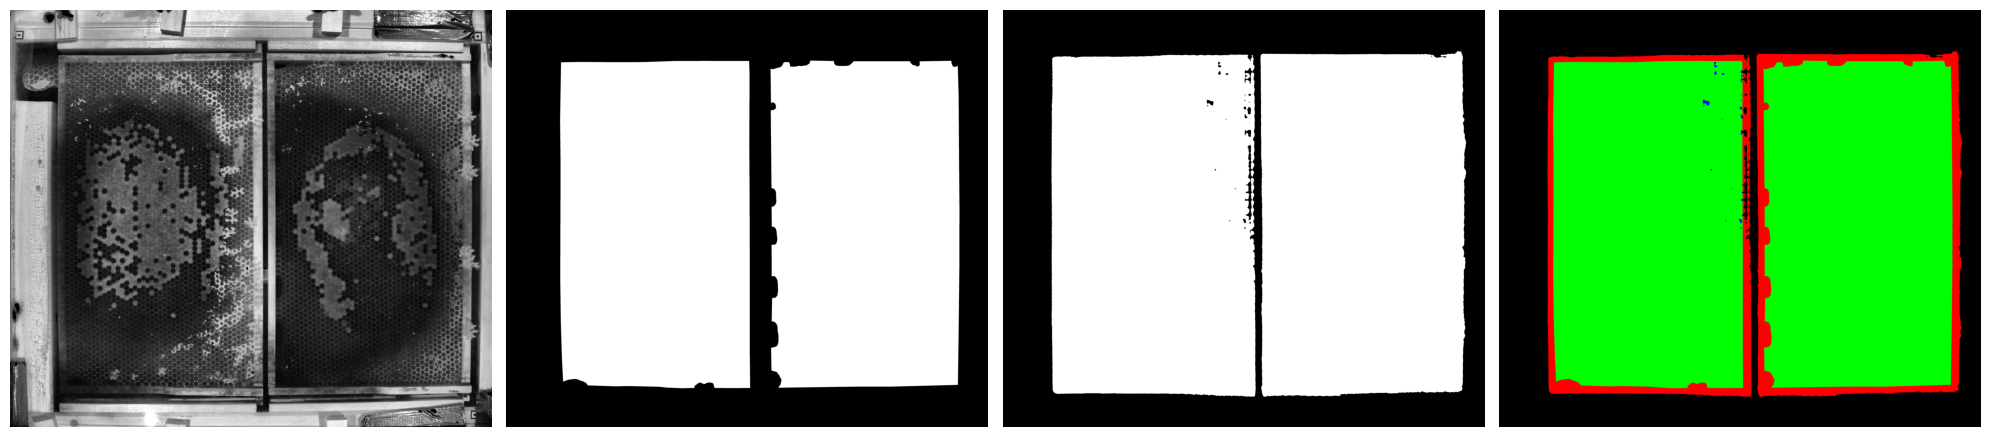

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [12]:
# Generate individual plots for each sample (thesis-ready, no titles/names)
individual_figures = evaluator.visualize_individual_samples(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    input_images=input_images,
    figsize_per_subplot=(5, 5)
)

print(f"Generated {len(individual_figures)} individual figures")

# Display all figures
for i, (fig, axes) in enumerate(individual_figures):
    plt.figure(fig.number)
    plt.show()

## Save Individual Figures (High Quality for Thesis)

In [13]:
date_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_name = f"sam_vit_h_points_2frames_multimask_true_{date_str}"

In [14]:
# Save each figure individually with high DPI for thesis
thesis_figures_dir = root_dir / "thesis_figures" / run_name
thesis_figures_dir.mkdir(parents=True, exist_ok=True)

for i, (fig, axes) in enumerate(individual_figures):
    # Save with high quality
    output_path = thesis_figures_dir / f"sample_{i+1}.png"
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path.name}")

    # Close to free memory
    plt.close(fig)

print(f"\n✓ All {len(individual_figures)} figures saved to: {thesis_figures_dir}")

Saved: sample_1.png
Saved: sample_2.png
Saved: sample_2.png
Saved: sample_3.png
Saved: sample_3.png
Saved: sample_4.png

✓ All 4 figures saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\thesis_figures\sam_vit_h_points_2frames_multimask_true_2025-11-20_23-40-56
Saved: sample_4.png

✓ All 4 figures saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\thesis_figures\sam_vit_h_points_2frames_multimask_true_2025-11-20_23-40-56


## Save Results

In [13]:
# Save all results with timestamp
date_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_name = f"sam_vit_h_points_2frames_multimask_true_{date_str}"

saved_paths = evaluator.save_batch_results(
    aggregate_metrics=aggregate_metrics,
    per_image_metrics=per_image_metrics,
    output_dir=root_dir / "results",
    run_name=run_name,
    save_figure=True,
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    input_images=input_images,
    image_names=image_names
)

print("\n✓ Results saved!")
for key, path in saved_paths.items():
    print(f"  {key}: {path}")

✓ Aggregate metrics saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\sam_vit_h_points_2frames_multimask_true_2025-11-15_22-44-55\aggregate_metrics.json
✓ Per-image metrics saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\sam_vit_h_points_2frames_multimask_true_2025-11-15_22-44-55\per_image_metrics.json
✓ Visualization saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\sam_vit_h_points_2frames_multimask_true_2025-11-15_22-44-55\visualization.png
✓ Summary saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\sam_vit_h_points_2frames_multimask_true_2025-11-15_22-44-55\summary.txt

All results saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\sam_vit_h_points_2frames_multimask_true_2025-11-15_22-44-55


✓ Results saved!
  aggregate: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmenta